# Statistics - Lab 1

**Deadline**: Check precise dates for each seminar group in the AG deliverable.

**Submission Guidelines**: Submit your work as a Jupyter Notebook file (`Lab1.ipynb`) via the Aula Global platform. Ensure that your notebook includes all code, visualisations, and written explanations. Make sure to run all cells and to keep the outputs of the cells in the delivered notebook. Separate files such as `.docx`, `.pdf`, or standalone figures will not be accepted.  

To ensure reproducibility, test your notebook on google Colab. If the code fails to execute, your submission will be graded as **0**.


Libraries imports to be used through the whole Lab:

In [200]:
import statistics
import matplotlib.pyplot as plt
import numpy as np
import scipy

## Question 1

> Maximum score: _1 point_

Write a function that generates 100 samples from a normal distribution with a mean of 10 and a standard deviation of 2. Use the `numpy.random.normal()` function to generate the samples.  

1. Plot a histogram for the sample data and adjust the number of bins to make the histogram resemble the shape of a normal distribution. Use the `matplotlib` library to create the plot.  
2. Generate a new set of 100 samples and plot another histogram.  
3. Repeat this process 5 times (i.e., draw 5 different samples and plot their histograms).

Store the 5 samplers in a variable so that you can access it from the next cells.

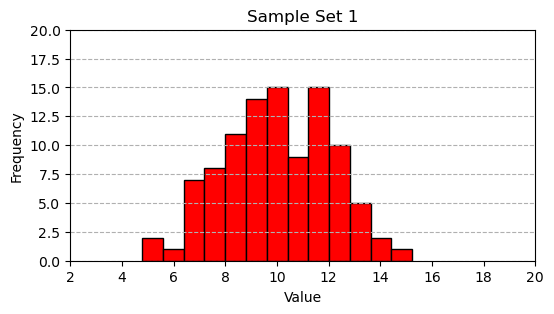

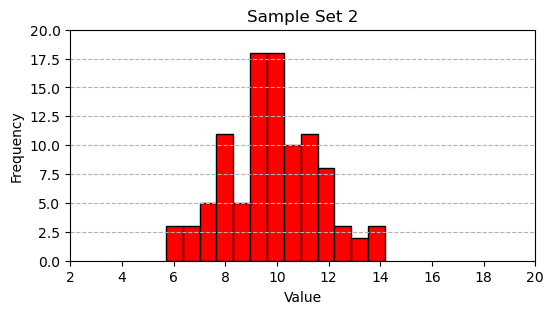

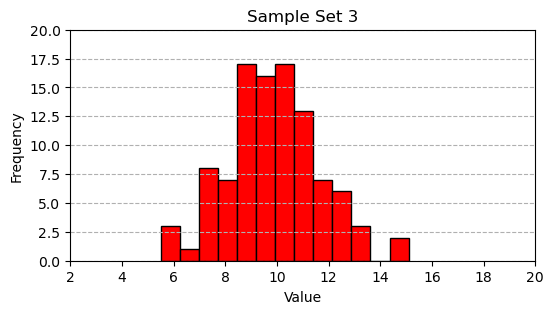

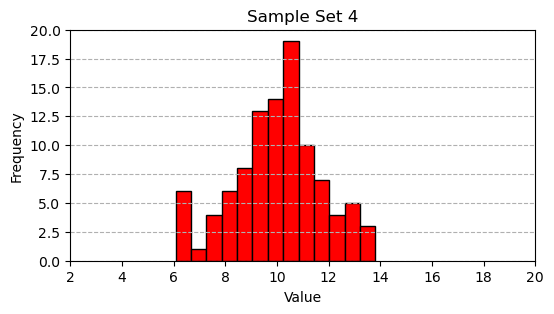

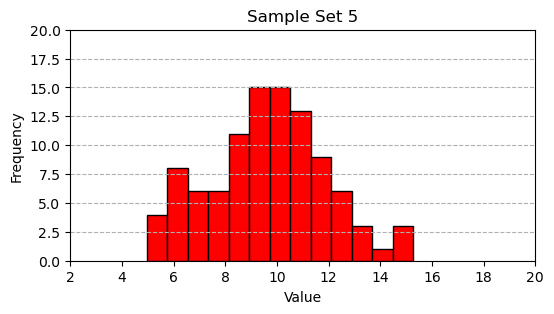

In [201]:
import numpy

def random_samples (mean =10, stdev=2, n=100):
    return numpy.random.normal(mean, stdev, n)


samples = [];

for i in range (5):
    current = random_samples()
    samples.append(current)

    plt.figure(figsize=(6, 3))
    plt.hist(current, bins=13, color='red', edgecolor='black')
    plt.title(f"Sample Set {i+1}")
    plt.xlabel("Value")
    plt.xticks([2,4,6,8,10,12,14,16,18,20])
    plt.ylabel("Frequency")
    plt.yticks([0, 2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20])
    plt.grid(axis='y', linestyle='--')
    plt.show()


### **Question**: Why do the histograms differ in appearance across the 5 experiments?  

Because as they are 5 different random samples, the result and the appearence are different. As a defined sample can't represent the total population, there is a sampling error variance in each, representing different values.

## Question 2  

> Maximum score: _0.5 point_

Write a function to calculate the mean value of a sample (without using Numpy’s nor Scipy's built-in `sum()` or `mean()` functions). Compare your result to the `statistics.mean()` function. Use the custom-made function to compute the sample mean for each of the 5 experiments from the previous question.

In [202]:
def mean_sample (sample):
    total =0
    for i in range (0,len(sample)):
        total+= sample[i]
    return total / len(sample)

for j in range (0, len(samples)):
    mean_sample1 = mean_sample(samples[j])
    print (f"Sample mean result {j+1}:" , mean_sample1 )
    mean_sample_function = statistics.mean(samples[j])
    print (f"Sample mean comparison result {j+1}:", mean_sample_function)
    print ("\n")


Sample mean result 1: 10.044798388069642
Sample mean comparison result 1: 10.04479838806964


Sample mean result 2: 9.851739136062351
Sample mean comparison result 2: 9.851739136062356


Sample mean result 3: 9.866158057722387
Sample mean comparison result 3: 9.866158057722386


Sample mean result 4: 10.024677973529919
Sample mean comparison result 4: 10.024677973529917


Sample mean result 5: 9.668905056050722
Sample mean comparison result 5: 9.668905056050724




### **Question**: Why does the sample mean differ across experiments?


The same way all histograms differ, the sample mean also does due to the sampling error. As we can't represent all values, each experiment represent a different part of the total population represented in the normal distribution.

## Question 3  

> Maximum score: _0.5 point_

Write a function to calculate the sample standard deviation without using built-in functions. Compare your result to Python's `statistics.stdev()` function.  

Use the custom-made function to compute the sample standard deviation for the 5 experiments from the previous question.  

In [203]:
def sample_stdev(sample, sample_mean):
    total_sum = 0
    for i in range (0, len(sample)):
        total_sum += (sample[i] - sample_mean)**2
    variance = total_sum / (len (sample)-1)
    return np.sqrt(variance)

for j in range (0, len(samples)):
    current_sample = samples[j]
    current_mean = mean_sample(current_sample)
    stdev_sample1 = sample_stdev(samples[j], current_mean)
    print (f"Sample stdev result {j+1}:" , stdev_sample1 )
    stdev_sample_function = statistics.stdev(samples[j])
    print (f"Sample stdev comparison result {j+1}:", stdev_sample_function)
    print("\n")


Sample stdev result 1: 2.1048141415807557
Sample stdev comparison result 1: 2.1048141415807553


Sample stdev result 2: 1.7967714379347954
Sample stdev comparison result 2: 1.7967714379347957


Sample stdev result 3: 1.8206729054296216
Sample stdev comparison result 3: 1.8206729054296218


Sample stdev result 4: 1.709651256628611
Sample stdev comparison result 4: 1.7096512566286108


Sample stdev result 5: 2.272820315412649
Sample stdev comparison result 5: 2.272820315412649




### **Question**: Why does the sample standard deviation differ across the experiments?

For the same reason as the mean, in this case the individual data sample will randomly differ in each case representing different variabilities, and thus, also the standar deviation for each experiment.

## Question 4  

> Maximum score: _1 point_

We will compare the histogram of the data with the probability density function (PDF) of the normal distribution using the maximum likelihood estimate (MLE) of the parameters. Plot the PDF of the normal distribution with the MLE parameters on top of the histogram from one of your previous experiments. The histogram should be normalized so that the y-axis represents a density estimate that can be compared to the PDF.  

Do not use built-in MLE functions from libraries.


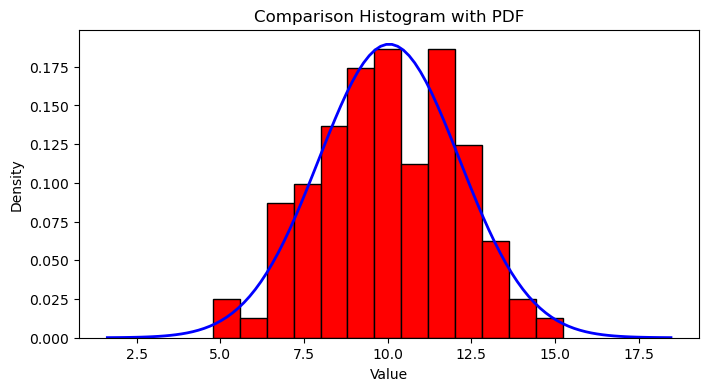

In [204]:
data = samples[0]

mle_sample_mean = mean_sample(data)
mle_stdev = sample_stdev(data, mle_sample_mean)

x = np.linspace(mle_sample_mean - 4*mle_stdev, mle_sample_mean + 4*mle_stdev, 100)

pdf = (1 / (mle_stdev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mle_sample_mean) / mle_stdev)**2)

plt.figure(figsize=(8, 4))
plt.hist(data, bins=13, density=True, color='red', edgecolor='black')

plt.plot(x, pdf, color='blue', linewidth=2)

plt.title("Comparison Histogram with PDF")
plt.xlabel("Value")
plt.ylabel("Density")

plt.show()

## Question 5  

> Maximum score: _2 points_

Write a function to calculate a confidence interval for the distribution mean at a given confidence level $1-α$. You can use `scipy.stats.norm.ppf()` (inverse of the cumulative distribution function of a standard normal) to calculate the critical $Z$ values, but you can't use `scipy.stats.norm.interval()`. Compare your results with those of `scipy.stats.norm.interval()`.

In [205]:
def confidence_interval(sign_level, sample):
    mean_interval=mean_sample(sample) 
    stdev_interval = sample_stdev(sample, mean_interval)
    conf_level = 1-sign_level
    z_value = abs(scipy.stats.norm.ppf(sign_level/2))
    min_val = mean_interval - z_value * (stdev_interval / np.sqrt(len(sample)))
    max_val = mean_interval + z_value * (stdev_interval / np.sqrt(len(sample)))
    print (f"{sign_level}   ||   {min_val}   ||   {max_val}   ")
    return
print ("alpha   ||   min_val   ||   max_val")
confidence_interval (0.5, samples[0])



alpha   ||   min_val   ||   max_val
0.5   ||   9.902830831613244   ||   10.18676594452604   


## Question 6

> Maximum score: *1 point*

Use the function written in Question 5 to fill in the following table for different significance levels $\alpha$ (for one of the previous experiments).

| $\alpha$ | Lower margin | Upper margin |
|----------|--------------|--------------|
| 0.50     |              |              |
| 0.10     |              |              |
| 0.05     |              |              |
| 0.01     |              |              |

In [206]:
print ("alpha   ||   Lower margin   ||   Upper margin")

confidence_interval (0.5, samples[0])
confidence_interval (0.1, samples[0])
confidence_interval (0.05, samples[0])
confidence_interval (0.01, samples[0])






alpha   ||   Lower margin   ||   Upper margin
0.5   ||   9.902830831613244   ||   10.18676594452604   
0.1   ||   9.698587270585856   ||   10.391009505553429   
0.05   ||   9.632262396904755   ||   10.45733437923453   
0.01   ||   9.50263419362886   ||   10.586962582510425   


### **Question**: What happens with the size of the confidence interval as the significance $\alpha$ decreases? Why is that?

If the level of significance decreases this results in having a more confident interval that contains a higher percentage of random samples.This means that for a lower level significance, the interval centered around the sample mean is wider containing more possible values.

This happens given that the z value for a lower significance level will be higher, and thus the interval is wider.

## Question 7

> Maximum score: *2 points*

Generate 100 experiments from the same normal distribution as above (mean 10 and std 2), each with sample size 100. Write a function to count the number of experiments where the theoretical value of the mean $\mu$ of the normal distribution falls inside the confidence intervals. Fill your results in the table below.

| $\alpha$ | Number    |
|----------|-----------|
| 0.50     | /100    |
| 0.10     | /100    |
| 0.05     | /100    |
| 0.01     | /100    |

In [207]:
def count_hits(alpha, num_experiments=100, n=100):
    hits = 0
    theoretical_mean = 10
    
    for _ in range(num_experiments):
        new_sample = random_samples(mean=10, stdev=2, n=n)
        
        new_mean = mean_sample(new_sample)
        new_stdev = sample_stdev(new_sample, new_mean)
        
        z = scipy.stats.norm.ppf(1 - alpha / 2)
        margin_error = z * (new_stdev / np.sqrt(n))
        lower = new_mean - margin_error
        upper = new_mean + margin_error
        
        if lower <= theoretical_mean <= upper:
            hits += 1
            
    return hits

print("   Alpha   |   Hits")
for a in [0.50, 0.10, 0.05, 0.01]:
    result = count_hits(a)
    print(f"   {a}   |   {result}/100")

   Alpha   |   Hits
   0.5   |   55/100
   0.1   |   88/100
   0.05   |   93/100
   0.01   |   98/100


### **Question**: For a confidence level $1-\alpha$, if you do $N$ experiments, computing for each sample the confidence intervals: how many of them do you expect to contain the population mean.

Given the population mean follows the normal distribution, the confidence interval should contain (1-alpha)*100 values exactly.

## Question 8

> Maximum score: *2 points*

Implement a hypothesis test for the null hypothesis that the population mean of the data is 10, and the one-sided alternative that the mean is smaller than 10.
You can use the fact that the data is normal and the standard deviation is known to be 2. Use a significance level $\alpha = 0.05$. Repeat the test if the alternative hypothesis is that the mean is larger than 10.

Do not use built-in functions that implement the entire test.

Print the output of the test, including:
- the value of the statistic
- the limits of the rejection region
- the result of the test (i.e. reject / fail to reject)


In [208]:
def hypothesis_test(sample, mean_0=10, stdev=2, alpha=0.05):
    n = len(sample)
    sample_mean = mean_sample(sample)
    
    # Z = (sample mean - mean_0) / (stdev / sqrt(n))
    standard_error = stdev / np.sqrt(n)
    z_stat = (sample_mean - mean_0) / standard_error
    
    print(f"Sample Mean: {sample_mean}")
    print(f"Test Statistic (Z): {z_stat:}")
    print ("\n")

    
    # Rejection region in left tail
    z_crit_left = scipy.stats.norm.ppf(alpha) 
    print(f"1. Alternative Hypothesis: Mean < {mean_0}")
    print(f"Rejection Region: Z < {z_crit_left}")
    
    if z_stat < z_crit_left:
        result_left = f"We reject Null Hypothesis as Z < Z({alpha})"
    else:
        result_left = f"We fail to Reject Null Hypothesis as Z > Z({alpha})"
    print(f"Result of test: {result_left}")
    
    print ("\n")

    #Rejection region in right tail
    z_crit_right = scipy.stats.norm.ppf(1 - alpha)
    print(f"2. Alternative Hypothesis: Mean > {mean_0}")
    print(f"Rejection Region: Z > {z_crit_right}")
    
    if z_stat > z_crit_right:
        result_right = f"We reject Null Hypothesis as Z > Z({alpha})"
    else:
        result_right = f"We fail to Reject Null Hypothesis as Z < Z({alpha})"
    print(f"Result of test: {result_right}")

hypothesis_test(samples[0])

Sample Mean: 10.044798388069642
Test Statistic (Z): 0.22399194034821157


1. Alternative Hypothesis: Mean < 10
Rejection Region: Z < -1.6448536269514729
Result of test: We fail to Reject Null Hypothesis as Z > Z(0.05)


2. Alternative Hypothesis: Mean > 10
Rejection Region: Z > 1.644853626951472
Result of test: We fail to Reject Null Hypothesis as Z < Z(0.05)
